In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from pathlib import Path

DATA_PATH = Path("cloudflare_ecosystem_2026.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place cloudflare_ecosystem_2026.csv in the notebook directory."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {DATA_PATH.name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")


Dataset loaded successfully: cloudflare_ecosystem_2026.csv
Rows: 1,882
Columns: 26


In [4]:
display(df.head())

,id,name,full_name,owner,owner_type,is_official_cloudflare,description,html_url,homepage,stars,forks,watchers,open_issues,stars_per_day,language,license,topics,queried_topic,created_at,updated_at,pushed_at,repo_age_days,days_since_last_push,size_kb,is_fork,archived
0,438384984,hono,honojs/hono,honojs,Organization,False,Web framework built on Web Standards,https://github.com/honojs/hono,https://hono.dev,31662,1219,31662,362,18.59,TypeScript,MIT,aws-lambda;bun;cloudflare;cloudflare-workers;d...,cloudflare-workers,2021-12-14 20:05:30+00:00,2026-08-14 13:18:51+00:00,2026-08-14 12:08:34+00:00,1703,0,9245,False,False
1,764287615,supermemory,supermemoryai/supermemory,supermemoryai,Organization,False,Memory and context engine + app that is extrem...,https://github.com/supermemoryai/supermemory,https://supermemory.ai/docs,28909,2514,28909,108,32.19,TypeScript,MIT,agent-memory;ai-memory;cloudflare-kv;cloudflar...,cloudflare-workers,2024-02-27 20:10:04+00:00,2026-08-14 13:19:20+00:00,2026-08-14 10:21:22+00:00,898,0,197460,False,False
2,636853988,pingora,cloudflare/pingora,cloudflare,Organization,True,"A library for building fast, reliable and evol...",https://github.com/cloudflare/pingora,NaN,27196,1713,27196,306,22.74,Rust,Apache-2.0,NaN,official-cloudflare-org,2023-05-05 20:03:08+00:00,2026-08-14 13:14:37+00:00,2026-08-07 21:09:04+00:00,1196,6,5411,False,False
3,18840003,react-starter-kit,kriasoft/react-starter-kit,kriasoft,Organization,False,"Modern React starter kit with Bun, TypeScript,...",https://github.com/kriasoft/react-starter-kit,https://reactstarter.com,23665,4205,23665,9,5.26,TypeScript,MIT,better-auth;boilerplate;bun;cloudflare;cloudfl...,cloudflare-workers,2014-04-16 13:08:18+00:00,2026-08-13 07:21:32+00:00,2026-08-11 18:00:58+00:00,4503,2,34002,False,False
4,669386969,Cloudflare-vless-trojan,yonggekkk/Cloudflare-vless-trojan,yonggekkk,User,False,CF-workers/pages代理脚本：支持Vless-ws(tls)、Trojan-ws...,https://github.com/yonggekkk/Cloudflare-vless-...,https://ygkkk.blogspot.com/2023/07/cfworkers-v...,15910,9633,15910,0,14.22,JavaScript,NaN,argo;cdn;clash-meta;cloudflare;cloudflare-page...,cloudflare-workers,2023-07-22 05:43:42+00:00,2026-08-14 10:32:52+00:00,2026-06-24 06:51:37+00:00,1119,51,165683,False,False


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Shape: (1882, 26)

Columns:
01. id
02. name
03. full_name
04. owner
05. owner_type
06. is_official_cloudflare
07. description
08. html_url
09. homepage
10. stars
11. forks
12. watchers
13. open_issues
14. stars_per_day
15. language
16. license
17. topics
18. queried_topic
19. created_at
20. updated_at
21. pushed_at
22. repo_age_days
23. days_since_last_push
24. size_kb
25. is_fork
26. archived


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1882 entries, 0 to 1881
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1882 non-null   int64  
 1   name                    1882 non-null   object 
 2   full_name               1882 non-null   object 
 3   owner                   1882 non-null   object 
 4   owner_type              1882 non-null   object 
 5   is_official_cloudflare  1882 non-null   bool   
 6   description             1811 non-null   object 
 7   html_url                1882 non-null   object 
 8   homepage                969 non-null    object 
 9   stars                   1882 non-null   int64  
 10  forks                   1882 non-null   int64  
 11  watchers                1882 non-null   int64  
 12  open_issues             1882 non-null   int64  
 13  stars_per_day           1882 non-null   float64
 14  language                1809 non-null   

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,"1,882.00","710,065,985.21","381,429,656.40","1,243,285.00","366,289,401.00","718,909,806.50","1,044,297,212.75","1,331,236,334.00"
stars,"1,882.00",409.23,"1,744.93",0.00,4.00,26.00,198.75,"31,662.00"
forks,"1,882.00",169.17,"1,435.45",0.00,0.00,5.00,35.00,"49,150.00"
watchers,"1,882.00",409.23,"1,744.93",0.00,4.00,26.00,198.75,"31,662.00"
open_issues,"1,882.00",9.02,37.59,0.00,0.00,1.00,6.00,653.00
stars_per_day,"1,882.00",0.84,5.11,0.00,0.01,0.03,0.20,115.19
repo_age_days,"1,882.00","1,232.27","1,054.40",2.00,353.25,"1,003.00","1,920.50","5,693.00"
days_since_last_push,"1,882.00",461.07,620.47,0.00,29.00,130.00,692.00,"3,338.00"
size_kb,"1,882.00","17,369.35","176,223.78",0.00,72.00,478.00,"2,913.75","5,716,214.00"


In [8]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(
          missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2)
      )
      .sort_values("missing_count", ascending=False)
)

display(missing)

,missing_count,missing_pct
homepage,913,48.51
license,488,25.93
topics,250,13.28
language,73,3.88
description,71,3.77
id,0,0.00
is_fork,0,0.00
size_kb,0,0.00
days_since_last_push,0,0.00
repo_age_days,0,0.00


In [9]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [10]:
categorical_cols = df.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Categorical / boolean columns:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))

Categorical / boolean columns:

--- name ---
name
cloudflare-ddns            6
blog                       5
homelab                    5
website                    4
portfolio                  3
link-shortener             3
edgetunnel                 3
url-shortener              3
workers                    3
cloudflare-dns-updater     2
Cloudflare-DDNS-Update     2
cf-url-shortener           2
cloudflare-ddns-updater    2
cloudflared                2
docker-cloudflared         2
Name: count, dtype: int64

--- full_name ---
full_name
honojs/hono                               1
matthewgall/cyberchef.app                 1
ShashankGupta10/Nymbus                    1
de956/browser-privacy                     1
rromenskyi/terraform-minikube-platform    1
robertgroarke/remote-agent-chat           1
BetaHuhn/cf-worker-starter                1
davidmytton/cloudflared-freebsd           1
seramo/shuffle-sub-worker                 1
axodotdev/octolotl                        1
umstek/edge-comments

In [11]:
data = df.copy()
data.columns = (
    data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)
text_cols = data.select_dtypes(include="object").columns
for col in text_cols:
    data[col] = data[col].str.strip()

date_cols = ["created_at", "updated_at", "pushed_at"]
for col in date_cols:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce", utc=True)

before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
removed = before - len(data)

print(f"Rows before duplicate removal: {before:,}")
print(f"Duplicate rows removed: {removed:,}")
print(f"Rows after cleaning: {len(data):,}")

Rows before duplicate removal: 1,882
Duplicate rows removed: 0
Rows after cleaning: 1,882


In [12]:
if {"forks", "stars"}.issubset(data.columns):
    data["fork_to_star_ratio"] = np.where(
        data["stars"] > 0,
        data["forks"] / data["stars"],
        0
    )

if {"open_issues", "stars"}.issubset(data.columns):
    data["issues_per_1000_stars"] = np.where(
        data["stars"] > 0,
        data["open_issues"] / data["stars"] * 1000,
        0
    )

if "days_since_last_push" in data.columns:
    data["activity_status"] = pd.cut(
        data["days_since_last_push"],
        bins=[-np.inf, 7, 30, 90, 180, 365, np.inf],
        labels=[
            "Very Active (≤7d)",
            "Active (8–30d)",
            "Recently Active (31–90d)",
            "Moderately Active (91–180d)",
            "Low Activity (181–365d)",
            "Stale (>365d)"
        ]
    )

if "repo_age_days" in data.columns:
    data["repo_age_years"] = data["repo_age_days"] / 365.25
    data["repo_age_group"] = pd.cut(
        data["repo_age_years"],
        bins=[-np.inf, 1, 3, 5, 10, np.inf],
        labels=["<1 year", "1–3 years", "3–5 years", "5–10 years", "10+ years"]
    )

print("Feature engineering completed.")
display(data.head())

Feature engineering completed.


,id,name,full_name,owner,owner_type,is_official_cloudflare,description,html_url,homepage,stars,forks,watchers,open_issues,stars_per_day,language,license,topics,queried_topic,created_at,updated_at,pushed_at,repo_age_days,days_since_last_push,size_kb,is_fork,archived,fork_to_star_ratio,issues_per_1000_stars,activity_status,repo_age_years,repo_age_group
0,438384984,hono,honojs/hono,honojs,Organization,False,Web framework built on Web Standards,https://github.com/honojs/hono,https://hono.dev,31662,1219,31662,362,18.59,TypeScript,MIT,aws-lambda;bun;cloudflare;cloudflare-workers;d...,cloudflare-workers,2021-12-14 20:05:30+00:00,2026-08-14 13:18:51+00:00,2026-08-14 12:08:34+00:00,1703,0,9245,False,False,0.04,11.43,Very Active (≤7d),4.66,3–5 years
1,764287615,supermemory,supermemoryai/supermemory,supermemoryai,Organization,False,Memory and context engine + app that is extrem...,https://github.com/supermemoryai/supermemory,https://supermemory.ai/docs,28909,2514,28909,108,32.19,TypeScript,MIT,agent-memory;ai-memory;cloudflare-kv;cloudflar...,cloudflare-workers,2024-02-27 20:10:04+00:00,2026-08-14 13:19:20+00:00,2026-08-14 10:21:22+00:00,898,0,197460,False,False,0.09,3.74,Very Active (≤7d),2.46,1–3 years
2,636853988,pingora,cloudflare/pingora,cloudflare,Organization,True,"A library for building fast, reliable and evol...",https://github.com/cloudflare/pingora,NaN,27196,1713,27196,306,22.74,Rust,Apache-2.0,NaN,official-cloudflare-org,2023-05-05 20:03:08+00:00,2026-08-14 13:14:37+00:00,2026-08-07 21:09:04+00:00,1196,6,5411,False,False,0.06,11.25,Very Active (≤7d),3.27,3–5 years
3,18840003,react-starter-kit,kriasoft/react-starter-kit,kriasoft,Organization,False,"Modern React starter kit with Bun, TypeScript,...",https://github.com/kriasoft/react-starter-kit,https://reactstarter.com,23665,4205,23665,9,5.26,TypeScript,MIT,better-auth;boilerplate;bun;cloudflare;cloudfl...,cloudflare-workers,2014-04-16 13:08:18+00:00,2026-08-13 07:21:32+00:00,2026-08-11 18:00:58+00:00,4503,2,34002,False,False,0.18,0.38,Very Active (≤7d),12.33,10+ years
4,669386969,Cloudflare-vless-trojan,yonggekkk/Cloudflare-vless-trojan,yonggekkk,User,False,CF-workers/pages代理脚本：支持Vless-ws(tls)、Trojan-ws...,https://github.com/yonggekkk/Cloudflare-vless-...,https://ygkkk.blogspot.com/2023/07/cfworkers-v...,15910,9633,15910,0,14.22,JavaScript,NaN,argo;cdn;clash-meta;cloudflare;cloudflare-page...,cloudflare-workers,2023-07-22 05:43:42+00:00,2026-08-14 10:32:52+00:00,2026-06-24 06:51:37+00:00,1119,51,165683,False,False,0.61,0.00,Recently Active (31–90d),3.06,3–5 years


In [13]:
kpis = {
    "Total repositories": len(data),
    "Total stars": data["stars"].sum() if "stars" in data.columns else np.nan,
    "Total forks": data["forks"].sum() if "forks" in data.columns else np.nan,
    "Total watchers": data["watchers"].sum() if "watchers" in data.columns else np.nan,
    "Official Cloudflare repositories": (
        data["is_official_cloudflare"].sum()
        if "is_official_cloudflare" in data.columns else np.nan
    ),
    "Archived repositories": (
        data["archived"].sum()
        if "archived" in data.columns else np.nan
    ),
}

kpi_df = pd.DataFrame(
    {"Metric": list(kpis.keys()), "Value": list(kpis.values())}
)

display(kpi_df)

,Metric,Value
0,Total repositories,1882
1,Total stars,770170
2,Total forks,318380
3,Total watchers,770170
4,Official Cloudflare repositories,300
5,Archived repositories,153


In [14]:
if "is_official_cloudflare" in data.columns:
    ownership_summary = (
        data["is_official_cloudflare"]
        .map({True: "Official Cloudflare", False: "Community / Other"})
        .value_counts()
        .rename_axis("repository_group")
        .reset_index(name="repositories")
    )
    ownership_summary["percentage"] = (
        ownership_summary["repositories"] / len(data) * 100
    ).round(2)

    display(ownership_summary)

,repository_group,repositories,percentage
0,Community / Other,1582,84.06
1,Official Cloudflare,300,15.94


In [15]:
if "owner_type" in data.columns:
    owner_summary = (
        data["owner_type"]
        .value_counts()
        .rename_axis("owner_type")
        .reset_index(name="repositories")
    )
    owner_summary["percentage"] = (
        owner_summary["repositories"] / len(data) * 100
    ).round(2)

    display(owner_summary)

,owner_type,repositories,percentage
0,User,1343,71.36
1,Organization,539,28.64


In [16]:
if "language" in data.columns:
    language_summary = (
        data["language"]
        .fillna("Unknown")
        .value_counts()
        .rename_axis("language")
        .reset_index(name="repositories")
    )

    language_summary["percentage"] = (
        language_summary["repositories"] / len(data) * 100
    ).round(2)

    display(language_summary.head(15))

,language,repositories,percentage
0,TypeScript,681,36.18
1,JavaScript,399,21.20
2,Go,125,6.64
3,Shell,110,5.84
4,Python,97,5.15
5,Rust,77,4.09
6,Unknown,73,3.88
7,HTML,57,3.03
8,HCL,33,1.75
9,Vue,30,1.59


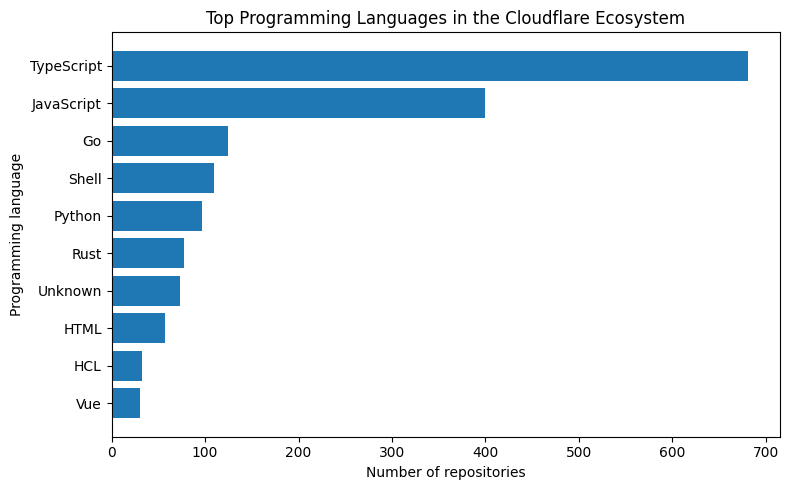

In [17]:
if "language" in data.columns:
    top_languages = language_summary.head(10).sort_values("repositories")

    plt.figure(figsize=(8,5))
    plt.barh(top_languages["language"], top_languages["repositories"])
    plt.xlabel("Number of repositories")
    plt.ylabel("Programming language")
    plt.title("Top Programming Languages in the Cloudflare Ecosystem")
    plt.tight_layout()
    plt.show()

In [18]:
popularity_cols = [
    col for col in [
        "full_name", "stars", "forks", "watchers",
        "language", "is_official_cloudflare",
        "days_since_last_push", "repo_age_days"
    ]
    if col in data.columns
]

top_by_stars = data.sort_values("stars", ascending=False)[popularity_cols].head(15)
display(top_by_stars)

,full_name,stars,forks,watchers,language,is_official_cloudflare,days_since_last_push,repo_age_days
0,honojs/hono,31662,1219,31662,TypeScript,False,0,1703
1,supermemoryai/supermemory,28909,2514,28909,TypeScript,False,0,898
2,cloudflare/pingora,27196,1713,27196,Rust,True,6,1196
3,kriasoft/react-starter-kit,23665,4205,23665,TypeScript,False,2,4503
4,yonggekkk/Cloudflare-vless-trojan,15910,9633,15910,JavaScript,False,51,1119
5,cloudflare/cloudflared,15225,1400,15225,Go,True,0,3226
6,maillab/cloud-mail,13403,19920,13403,JavaScript,False,4,477
7,cloudflare/quiche,11766,1059,11766,Rust,True,0,2875
8,dreamhunter2333/cloudflare_temp_email,11295,7630,11295,TypeScript,False,3,1094
9,cloudflare/moltworker,9936,1742,9936,TypeScript,True,97,199


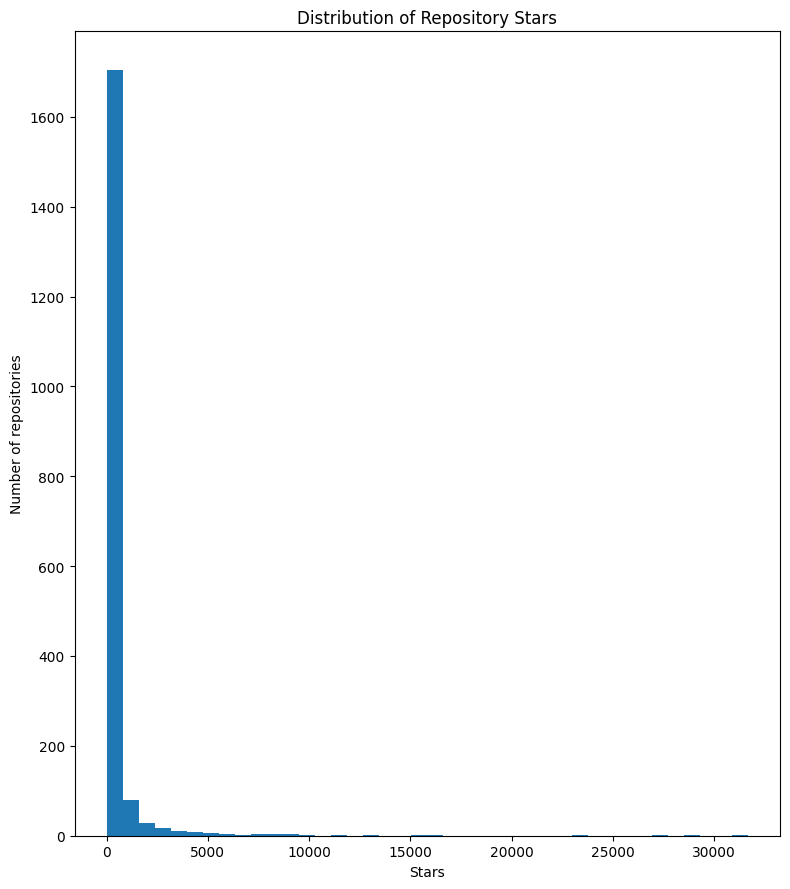

In [19]:
if "stars" in data.columns:
    plt.figure(figsize=(8, 9))
    plt.hist(data["stars"].clip(lower=0), bins=40)
    plt.xlabel("Stars")
    plt.ylabel("Number of repositories")
    plt.title("Distribution of Repository Stars")
    plt.tight_layout()
    plt.show()

In [20]:
if "activity_status" in data.columns:
    activity_summary = (
        data["activity_status"]
        .value_counts()
        .reindex([
            "Very Active (≤7d)",
            "Active (8–30d)",
            "Recently Active (31–90d)",
            "Moderately Active (91–180d)",
            "Low Activity (181–365d)",
            "Stale (>365d)"
        ])
        .fillna(0)
        .astype(int)
        .rename_axis("activity_status")
        .reset_index(name="repositories")
    )

    activity_summary["percentage"] = (
        activity_summary["repositories"] / len(data) * 100
    ).round(2)

    display(activity_summary)


,activity_status,repositories,percentage
0,Very Active (≤7d),299,15.89
1,Active (8–30d),187,9.94
2,Recently Active (31–90d),201,10.68
3,Moderately Active (91–180d),345,18.33
4,Low Activity (181–365d),157,8.34
5,Stale (>365d),693,36.82


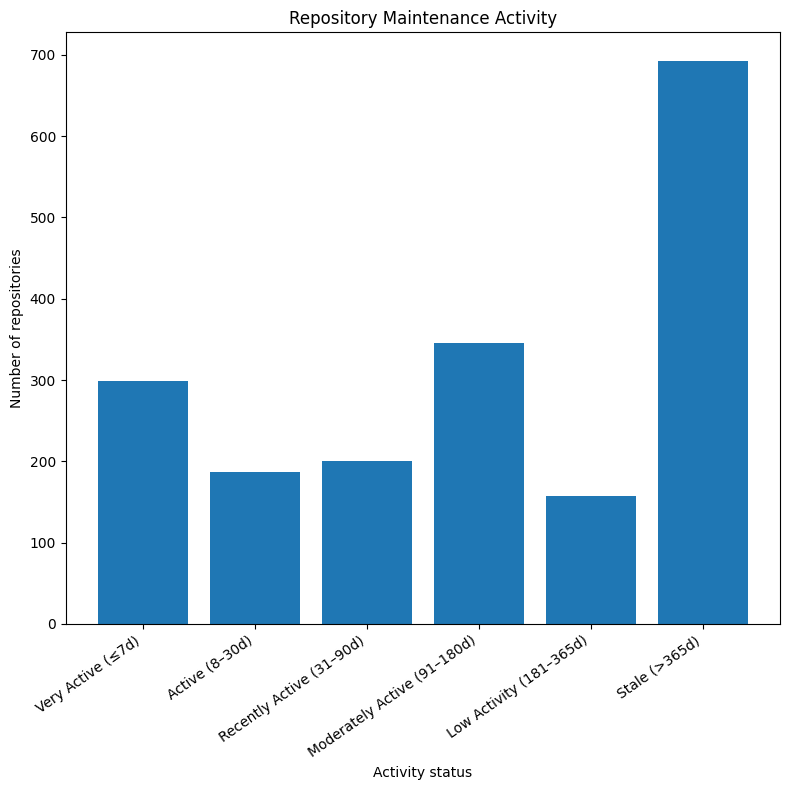

In [21]:
if "activity_status" in data.columns:
    plt.figure(figsize=(8,8))
    plt.bar(activity_summary["activity_status"], activity_summary["repositories"])
    plt.xlabel("Activity status")
    plt.ylabel("Number of repositories")
    plt.title("Repository Maintenance Activity")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
